<a href="https://colab.research.google.com/github/keshavgamerfree-a11y/ArtificalAdvanced_NeuralNetworks/blob/main/099_ANN_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LAB 3 - ARTIFICAL ADVANCED NEURAL NETWORKS**

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/weight-height (1).csv')
display(df.head())

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
X = df[['Weight']]
y = df['Height']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (8000, 1)
Shape of X_test: (2000, 1)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [4]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

In [5]:
regressor.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = regressor.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 1.1589
Mean Squared Error (MSE): 2.1124
Root Mean Squared Error (RMSE): 1.4534
R-squared (R2): 0.8578


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

df_duration = pd.read_csv('/content/weight-height (1).csv')

df_duration['duration_class'] = pd.cut(df_duration['Time (min)'],
                                     bins=[-1, 120, 360, np.inf],
                                     labels=[0, 1, 2],
                                     right=True,
                                     include_lowest=True).astype(int)

display(df_duration.head())

,Gender,Height,Weight,duration_class
0,Male,73.847017,241.893563,1
1,Male,68.781904,162.310473,1
2,Male,74.110105,212.740856,1
3,Male,71.730978,220.042470,1
4,Male,69.881796,206.349801,1


Text(0.5, 1.0, 'Sigmoid Function')

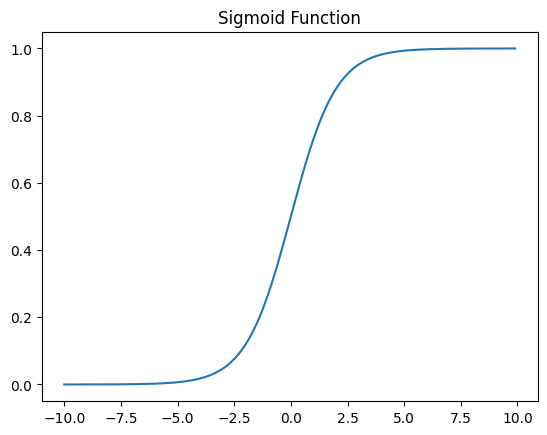

In [11]:
def sigmoid(z):
  return 1.0/(1.0 + np.exp(-z))
z = np.arange(-10,10,0.1)
plt.plot(z, sigmoid(z))

plt.title('Sigmoid Function')


### Preprocessing the Data

We need to:
1.  **Separate features (X) and target (y)**.
2.  **Scale numerical features**: Standardize features to improve model performance.
3.  **Split data**: Divide the dataset into training and testing sets.

In [17]:
X = df_duration.drop(['Weight', 'duration_class'], axis=1)
y = df_duration['duration_class']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply LabelEncoder to 'Gender' column
le = LabelEncoder()
X_train_cls['Gender'] = le.fit_transform(X_train_cls['Gender'])
X_test_cls['Gender'] = le.transform(X_test_cls['Gender'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cls)
X_test_scaled = scaler.transform(X_test_cls)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")

Shape of X_train_scaled: (8000, 2)
Shape of X_test_scaled: (2000, 2)
Shape of y_train_cls: (8000,)
Shape of y_test_cls: (2000,)


In [22]:
try:
    input_shape = X_train_scaled.shape[1]
    num_classes = len(y.unique())
except NameError as e:
    print(f"Error: {e}. It appears that variables from previous cells (like X_train_scaled and y) are not defined.")
    print("Please ensure you have run all preceding cells, especially the data preprocessing and splitting cell.")
    # Using placeholder values to allow the model definition to proceed
    # Based on previous successful run, X_train_scaled has 2 features and y has 3 unique classes.
    input_shape = 2
    num_classes = 3
    print(f"Using placeholder input_shape={input_shape} and num_classes={num_classes} to define the model. \n***Please re-run previous cells for correct values before training.***")

model = keras.Sequential([
    layers.InputLayer(input_shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338 (9.13 KB)

 Trainable params: 2,338 (9.13 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

Now, we'll train the sequential model using the scaled training data. We'll set the number of `epochs` and use a `batch_size`.

In [19]:
epochs = 50
batch_size = 32

history = model.fit(X_train_scaled, y_train_cls, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

print("\nModel training complete.")

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8955 - loss: 0.2569 - val_accuracy: 0.9356 - val_loss: 0.1417
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9369 - loss: 0.1421 - val_accuracy: 0.9400 - val_loss: 0.1409
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9388 - loss: 0.1410 - val_accuracy: 0.9350 - val_loss: 0.1407
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9395 - loss: 0.1372 - val_accuracy: 0.9350 - val_loss: 0.1416
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9395 - loss: 0.1388 - val_accuracy: 0.9400 - val_loss: 0.1411
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9419 - loss: 0.1348 - val_accuracy: 0.9319 - val_loss: 0.1433
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9395 - loss: 0.1351 - val_accuracy: 0.9350 - val_loss: 0.1429
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9392 - loss: 0.1373 - val_accuracy: 0.

### Evaluating the Model

Finally, we'll evaluate the trained model's performance on the unseen test data using the metrics defined during compilation (accuracy).

In [20]:
loss, accuracy = model.evaluate(X_test_scaled, y_test_cls, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_scaled)
y_pred_cls = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Test Loss: 0.1325
Test Accuracy: 0.9385
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68       203
           1       0.96      0.97      0.97      1797

    accuracy                           0.94      2000
   macro avg       0.84      0.81      0.82      2000
weighted avg       0.94      0.94      0.94      2000



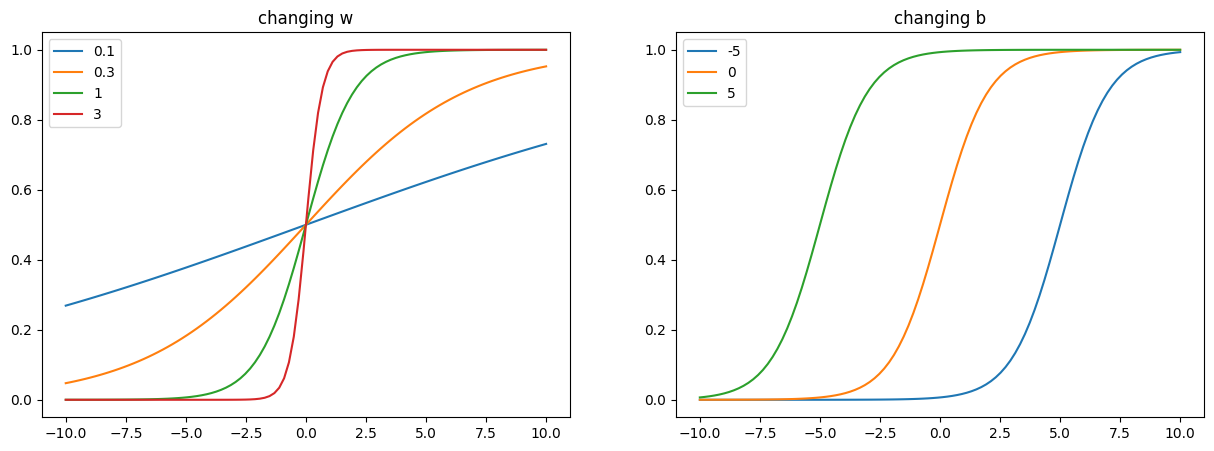

In [23]:
def line(x, w=1, b=0):
  return w*x + b

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(15, 5))
plt.subplot(121)
ws = [0.1,0.3,1,3]
for w in ws:
  plt.plot(x,sigmoid(line(x,w=w)))
plt.legend(ws)
plt.title('changing w')
plt.subplot(122)
bs = [-5,0,5]
for b in bs:
  plt.plot(x,sigmoid(line(x,b=b)))
plt.legend(bs)
plt.title('changing b');